


1. Загрузка gpkg (3425 ячеек с разрешением 500 на 500 м)

2. Определение ночного и дневного населения – ночь:  22–6; день: 11–13 (целевой период для прогнозирования).

**Радиационная модель**


$$T_{ij} = T_i \cdot \frac{m_i \, n_j}{(m_i + s_{ij})(m_i + n_j + s_{ij})}$$

- **m_i**: численность населения в *i* (ночное население).
- **n_j**: количество POI в *j*
- **s_ij**: сумма POI во всех ячейках, находящихся ближе к *i*, чем *j* 
- **T_i**: общий отток из *i* (0.6 * m_i)

1. Построение KDTree – пространственный индекс по центроидам ячеек для быстрых запросов расстояний/соседства.

2. Построение матрицы "Источник–Назначение" (OD) с  радиусом 15 км

3. Вычисление s_ij – для каждой пары OD (i,j) суммируются точки интереса (POI) в ячейках, которые ближе к i, чем к j, с использованием KDTree 

4. Вычисление потока T_ij от i к j с использованием m_i (ночное население в i), n_j (POI в j) и s_ij (сумма POI в заданном радиусе)



**Загрузка данных**

In [63]:
import geopandas as gpd
import pandas as pd
import numpy as np
from scipy.spatial import KDTree
from scipy.spatial.distance import cdist
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

GPKG_PATH = r"C:\Users\user\Desktop\hse geo\3 Kurs\Курсовая\gdf_500_with_poi.gpkg"

NIGHT_HOURS = list(range(22, 24)) + list(range(0, 7))
DAY_HOURS = [11, 12, 13]

MAX_OD_DISTANCE = 15000
COMMUTER_FRACTION = 0.6


In [33]:
gdf = gpd.read_file(GPKG_PATH)
print(f"Cells: {len(gdf):,}, CRS: {gdf.crs}, Columns: {list(gdf.columns)}")

hour_cols = [f'H{i}' for i in range(24)]
print("Колонки с часами:", hour_cols)

night_cols = ['H22', 'H23', 'H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6']
day_cols = ['H11', 'H12', 'H13']
poi_values = gdf['poi_count'].values 

gdf["nighttime_pop"] = gdf[night_cols].mean(axis=1).fillna(0)
gdf["daytime_pop_obs"] = gdf[day_cols].mean(axis=1).fillna(0)

print("Nighttime pop (22–6):", gdf["nighttime_pop"].describe())
print("Daytime pop (11–13) observed:", gdf["daytime_pop_obs"].describe())

Cells: 3,425, CRS: EPSG:3067, Columns: ['x500', 'y500', 'H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21', 'H22', 'H23', 'poi_count', 'geometry']
Колонки с часами: ['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21', 'H22', 'H23']
Nighttime pop (22–6): count     3425.000000
mean       337.216642
std        705.018261
min          0.000000
25%         11.888889
50%         65.555556
75%        371.666667
max      11633.555556
Name: nighttime_pop, dtype: float64
Daytime pop (11–13) observed: count     3425.000000
mean       337.216642
std        942.938903
min          0.000000
25%         12.666667
50%         69.000000
75%        317.333333
max      20210.000000
Name: daytime_pop_obs, dtype: float64


**Центроиды ячеек и KD-дерево для оптимизации**

In [3]:

gdf["centroid"] = gdf.geometry.centroid
coords = np.array([[p.x, p.y] for p in gdf["centroid"]])
n_cells = len(gdf)

tree = KDTree(coords)
print(f"KDTree built for {n_cells:,} points. Example query: 5 nearest to first point:")
dists, idxs = tree.query(coords[0], k=5)
print("  distances:", dists, "indices:", idxs)

KDTree built for 3,425 points. Example query: 5 nearest to first point:
  distances: [  0.         500.         500.         707.10678119 707.10678119] indices: [ 0  1 13 14 12]


**Матрица OD**

In [34]:
HOURS_NIGHT = len(night_cols)

m_i = gdf["nighttime_pop"].values

In [35]:
n_j = gdf["poi_count"].values

In [36]:
from tqdm import tqdm


od_list = []
if MAX_OD_DISTANCE is not None:
    
    print(f"Building OD pairs within {MAX_OD_DISTANCE}m radius...")
    for i in tqdm(range(n_cells), desc="Processing cells", unit="cell"):
        indices = tree.query_ball_point(coords[i], r=MAX_OD_DISTANCE)
        for j in indices:
            if i == j:
                continue
            d_ij = np.linalg.norm(coords[i] - coords[j])
            od_list.append((i, j, d_ij))
            
        
        if i % 1000 == 0 and i > 0:
            print(f"  Processed {i:,} cells, found {len(od_list):,} OD pairs so far")
else:
    
    print("Building all OD pairs (full matrix)...")
    for i in tqdm(range(n_cells), desc="Processing cells", unit="cell"):
        dists_i, indices_i = tree.query(coords[i], k=n_cells)
        for k in range(n_cells):
            j = indices_i[k]
            if i == j:
                continue
            od_list.append((i, j, dists_i[k]))
        
        
        if i % 500 == 0 and i > 0:
            print(f"  Processed {i:,} cells, found {len(od_list):,} OD pairs so far")

od_df = pd.DataFrame(od_list, columns=["origin_id", "dest_id", "distance"])
print(f"\n Число пар: {len(od_df):,}")

Building OD pairs within 15000m radius...


Processing cells:  30%|██▉       | 1016/3425 [00:09<00:28, 85.39cell/s]

  Processed 1,000 cells, found 1,446,479 OD pairs so far


Processing cells:  59%|█████▉    | 2018/3425 [00:21<00:15, 89.61cell/s] 

  Processed 2,000 cells, found 3,393,306 OD pairs so far


Processing cells:  88%|████████▊ | 3023/3425 [00:31<00:03, 124.88cell/s]

  Processed 3,000 cells, found 5,153,937 OD pairs so far


Processing cells: 100%|██████████| 3425/3425 [00:34<00:00, 100.04cell/s]



 Число пар: 5,669,248


In [37]:
print(od_df.head())

   origin_id  dest_id      distance
0          0      690  14916.433890
1          0      749  14866.068747
2          0      639  14212.670404
3          0      691  14534.441854
4          0      590  13509.256086


**Поиск s_ij**


In [38]:
import time
import numpy as np

def compute_intervening_kdtree(od_df, tree, coords, pop_values):
    print(f"Вычисление s_ij начато в {time.strftime('%H:%M:%S')}")
    start_time = time.time()
    
    
    origins = od_df["origin_id"].values.astype(int)
    destinations = od_df["dest_id"].values.astype(int)
    distances = od_df["distance"].values
    
    n_pairs = len(origins)
    s_ij_list = np.zeros(n_pairs, dtype=np.float32)  
    
    
    query_cache = {}
    
    
    pop_array = np.array(pop_values, dtype=np.float32)
    
    for idx in range(n_pairs):
        i = origins[idx]
        j = destinations[idx]
        d_ij = distances[idx]
        
        
        d_rounded = round(d_ij, 1) 
        
        
        cache_key = (i, d_rounded)
        if cache_key in query_cache:
            s_ij_sum = query_cache[cache_key]
            
            s_ij = s_ij_sum
            
        else:
           
            r = d_ij + 1e-9
            indices = tree.query_ball_point(coords[i], r=r)
            
            
            if indices:
                
                indices_arr = np.array(indices, dtype=int)
                
                
                mask = (indices_arr != i) & (indices_arr != j)
                valid_indices = indices_arr[mask]
                
                if len(valid_indices) > 0:
                    
                    s_ij_sum = np.sum(pop_array[valid_indices])
                    query_cache[cache_key] = s_ij_sum
                    s_ij = s_ij_sum
                else:
                    s_ij = 0.0
            else:
                s_ij = 0.0
        
        s_ij_list[idx] = s_ij
        
        
        if idx % 50000 == 0 and idx > 0:
            elapsed = time.time() - start_time
            speed = idx / elapsed
            print(f"  Обработано {idx:,} пар, прошло {elapsed:.0f} сек, "
                  f"скорость: {speed:.0f} пар/сек")
            
            
            remaining = n_pairs - idx
            if speed > 0:
                remaining_time = remaining / speed
                print(f"  Осталось: {remaining_time:.0f} сек ({remaining_time/60:.1f} мин)")
    
    total_time = time.time() - start_time
    print(f" Вычисление завершено! Всего времени: {total_time:.0f} сек")
    print(f"   Средняя скорость: {n_pairs/total_time:.0f} пар/сек")
    
    return s_ij_list


s_ij = compute_intervening_kdtree(od_df, tree, coords, poi_values)
od_df["s_ij"] = s_ij

Вычисление s_ij начато в 17:53:51
  Обработано 50,000 пар, прошло 3 сек, скорость: 18847 пар/сек
  Осталось: 298 сек (5.0 мин)
  Обработано 100,000 пар, прошло 5 сек, скорость: 19960 пар/сек
  Осталось: 279 сек (4.7 мин)
  Обработано 150,000 пар, прошло 7 сек, скорость: 20996 пар/сек
  Осталось: 263 сек (4.4 мин)
  Обработано 200,000 пар, прошло 11 сек, скорость: 17549 пар/сек
  Осталось: 312 сек (5.2 мин)
  Обработано 250,000 пар, прошло 16 сек, скорость: 15792 пар/сек
  Осталось: 343 сек (5.7 мин)
  Обработано 300,000 пар, прошло 20 сек, скорость: 14872 пар/сек
  Осталось: 361 сек (6.0 мин)
  Обработано 350,000 пар, прошло 24 сек, скорость: 14866 пар/сек
  Осталось: 358 сек (6.0 мин)
  Обработано 400,000 пар, прошло 28 сек, скорость: 14404 пар/сек
  Осталось: 366 сек (6.1 мин)
  Обработано 450,000 пар, прошло 32 сек, скорость: 14173 пар/сек
  Осталось: 368 сек (6.1 мин)
  Обработано 500,000 пар, прошло 36 сек, скорость: 14051 пар/сек
  Осталось: 368 сек (6.1 мин)
  Обработано 550,000

**Построение радиационной модели T_ij и нормализация**


In [40]:
import time
import numpy as np
from tqdm import tqdm

def radiation_prob(m_i, n_j, s_ij):
    denom = (m_i + s_ij) * (m_i + n_j + s_ij)
    if denom <= 0:
        return 0.0
    return (m_i * n_j) / denom


print(f"Начало: {time.strftime('%H:%M:%S')}")
total_start_time = time.time()


print("\n1. Расчет raw_flow...")
step1_start = time.time()


orig_pop = m_i[od_df["origin_id"].values]
dest_pop = n_j[od_df["dest_id"].values]
s_ij_vals = od_df["s_ij"].values


print("  Векторизованный расчет radiation_prob...")
raw_flow = np.zeros(len(od_df), dtype=np.float32)


batch_size = 1000000
n_batches = (len(od_df) + batch_size - 1) // batch_size

for batch in tqdm(range(n_batches), desc="Расчет raw_flow", unit="batch"):
    start_idx = batch * batch_size
    end_idx = min((batch + 1) * batch_size, len(od_df))
    
    batch_orig = orig_pop[start_idx:end_idx]
    batch_dest = dest_pop[start_idx:end_idx]
    batch_s_ij = s_ij_vals[start_idx:end_idx]
    
    
    denominators = (batch_orig + batch_s_ij) * (batch_orig + batch_dest + batch_s_ij)
    valid_mask = denominators > 0
    batch_result = np.zeros(len(batch_orig))
    batch_result[valid_mask] = (batch_orig[valid_mask] * batch_dest[valid_mask]) / denominators[valid_mask]
    
    raw_flow[start_idx:end_idx] = batch_result

od_df["raw_flow"] = raw_flow
step1_time = time.time() - step1_start
print(f"  ✓ Завершено за {step1_time:.1f} сек")


print("\n2. Нормализация P_ij...")
step2_start = time.time()

od_df["P_ij"] = 0.0
unique_origins = od_df["origin_id"].unique()


for i in tqdm(unique_origins, desc="Нормализация по origin", unit="origin"):
    mask = od_df["origin_id"] == i
    total = od_df.loc[mask, "raw_flow"].sum()
    if total > 0:
        od_df.loc[mask, "P_ij"] = od_df.loc[mask, "raw_flow"] / total

step2_time = time.time() - step2_start
print(f"  ✓ Завершено за {step2_time:.1f} сек")
print(f"  Обработано origins: {len(unique_origins):,}")


print("\n3. Расчет предсказанных потоков T_ij...")
step3_start = time.time()

T_i = COMMUTER_FRACTION * m_i
od_df["T_ij"] = T_i[od_df["origin_id"].values] * od_df["P_ij"].values

step3_time = time.time() - step3_start


total_time = time.time() - total_start_time

print("Результаты расчета")
print(f"Время выполнения: {total_time:.1f} сек ({total_time/60:.1f} мин)")
print(f"  - Шаг 1 (raw_flow): {step1_time:.1f} сек ({step1_time/total_time*100:.0f}%)")
print(f"  - Шаг 2 (P_ij): {step2_time:.1f} сек ({step2_time/total_time*100:.0f}%)")
print(f"  - Шаг 3 (T_ij): {step3_time:.1f} сек ({step3_time/total_time*100:.0f}%)")
print(f"Всего OD пар: {len(od_df):,}")
print(f"Ненулевых потоков: {(od_df['T_ij'] > 0).sum():,}")

print("\nPredicted flows T_ij:")
print(od_df["T_ij"].describe())

Начало: 18:42:26

1. Расчет raw_flow...
  Векторизованный расчет radiation_prob...


Расчет raw_flow: 100%|██████████| 6/6 [00:00<00:00, 12.19batch/s]


  ✓ Завершено за 0.6 сек

2. Нормализация P_ij...


Нормализация по origin: 100%|██████████| 3425/3425 [01:03<00:00, 54.12origin/s]


  ✓ Завершено за 63.4 сек
  Обработано origins: 3,425

3. Расчет предсказанных потоков T_ij...
Результаты расчета
Время выполнения: 64.0 сек (1.1 мин)
  - Шаг 1 (raw_flow): 0.6 сек (1%)
  - Шаг 2 (P_ij): 63.4 сек (99%)
  - Шаг 3 (T_ij): 0.1 сек (0%)
Всего OD пар: 5,669,248
Ненулевых потоков: 3,865,430

Predicted flows T_ij:
count    5.669248e+06
mean     1.222349e-01
std      1.251870e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.181405e-04
75%      6.070446e-03
max      2.749421e+02
Name: T_ij, dtype: float64


**Предсказание дневной плотности**


In [41]:
inflow_by_dest = od_df.groupby("dest_id")["T_ij"].sum()

predicted_day_pop = inflow_by_dest.reindex(gdf.index, fill_value=0).values
predicted_day_pop += (1 - COMMUTER_FRACTION) * m_i

gdf["daytime_pop_pred"] = predicted_day_pop

**Оценка результата радиационной модели**

In [ ]:
y_actual = gdf["daytime_pop_obs"].values
y_pred = gdf["daytime_pop_pred"].values

print(" Radiation Model Performance ")
print(f"  R² = {r2_score(y_actual, y_pred):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_actual, y_pred)):.4f}")
print(f"  Корреляция Пирсона: {pearsonr(y_actual, y_pred)[0]:.4f}")
print(f"  MAE = {mean_absolute_error(y_actual, y_pred):.4f}")

 Radiation Model Performance 
  R² = 0.7127
  RMSE = 505.3170
  Корреляция Пирсона: 0.8605
  MAE = 158.5910


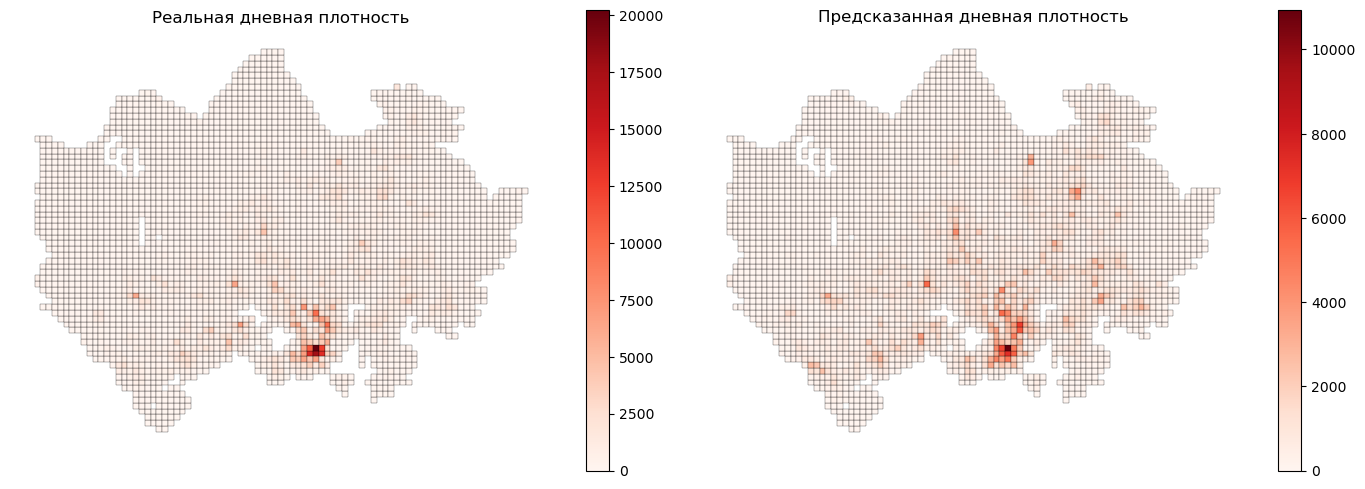

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


gdf.plot(column='daytime_pop_obs', ax=ax1, cmap='Reds', legend=True, edgecolor='black', linewidth=0.2)
ax1.set_title('Реальная дневная плотность')
ax1.axis('off')


gdf.plot(column='daytime_pop_pred', ax=ax2, cmap='Reds', legend=True, edgecolor='black', linewidth=0.2)
ax2.set_title('Предсказанная дневная плотность')
ax2.axis('off')

plt.tight_layout()
plt.show()

**Сохранение результатов радиационной модели**

In [45]:
gdf[gdf.columns.drop([col for col in gdf.columns if gdf[col].dtype.name == 'geometry' and col != gdf.geometry.name])].to_file(r"C:\Users\user\Desktop\hse geo\3 Kurs\Курсовая\daytime_population_predicted_rad.gpkg", driver="GPKG")

In [46]:
gdf.set_geometry("geometry").to_file(r"C:\Users\user\Desktop\hse geo\3 Kurs\Курсовая\daytime_population_predicted_rad.gpkg", driver="GPKG")

**Модель выбра приоритетных возможностей**



$$T_{ij} = O_i \cdot P_{ij} = O_i \cdot \frac{m_j / S_{ij}}{\sum_j m_j / S_{ij}}$$


- **O_i**: общий отток из *i*
- **m_j**: Возможности в точке назначения (количество точек интереса - POI) в *j*
- **S_ij**: Кумулятивные (накопленные) возможности (POI) от источника *i* до назначения *j* 



In [ ]:
gdf = gpd.read_file(GPKG_PATH)
hour_cols = [f'H{i}' for i in range(24)]

daytime_cols = ['H11', 'H12', 'H13']
nighttime_cols = ['H22', 'H23', 'H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6']

gdf['daytime_density'] = gdf[daytime_cols].mean(axis=1)
gdf['nighttime_density'] = gdf[nighttime_cols].mean(axis=1)
poi_col = gdf['poi_count']

In [69]:
def compute_ops_flows_grouped(O, m, dist_matrix, eps=1e-10):
    n = len(O)
    T = np.zeros((n, n))

    for i in range(n):
        dists = dist_matrix[i]

        
        unique_dists = np.unique(dists)

        m_over_S = np.zeros(n)
        S_cumul = 0

        for d in unique_dists:
            
            mask = (dists == d)
            indices = np.where(mask)[0]

           
            m_group = m[indices].sum()

            
            S_cumul = S_cumul + m_group
            S_cumul = max(S_cumul, eps)

            
            for j in indices:
                m_over_S[j] = m[j] / S_cumul

        
        denom = m_over_S.sum()
        if denom < eps:
            P_i = np.ones(n) / n
        else:
            P_i = m_over_S / denom

        T[i, :] = O[i] * 0.6 * P_i
        T[i, i] += O[i] * 0.4

    return T

gdf_centroids = gdf.copy()
gdf_centroids['centroid'] = gdf.geometry.centroid
coords = np.column_stack([
    gdf_centroids['centroid'].x.values,
    gdf_centroids['centroid'].y.values
])


dist_matrix = cdist(coords, coords)

O = gdf['nighttime_density'].values
m = gdf['poi_count'].values + 1e-10


T = compute_ops_flows_grouped(O, m, dist_matrix)


daytime_predicted = T.sum(axis=0)
gdf['daytime_density_predicted'] = daytime_predicted
gdf['daytime_density_residual'] = gdf['daytime_density'] - daytime_predicted 


**Оценка модели выбора приоритетных возможностей**

In [70]:
y_actual = gdf["daytime_density"].values
y_pred = gdf["daytime_density_predicted"].values

print(" Opportunity Priority Selection Model Performance ")
print(f"  R² = {r2_score(y_actual, y_pred):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_actual, y_pred)):.4f}")
print(f"  Корреляция Пирсона: {pearsonr(y_actual, y_pred)[0]:.4f}")
print(f"  MAE = {mean_absolute_error(y_actual, y_pred):.4f}")

 Opportunity Priority Selection Model Performance 
  R² = 0.7513
  RMSE = 470.1703
  Корреляция Пирсона: 0.8813
  MAE = 148.4195


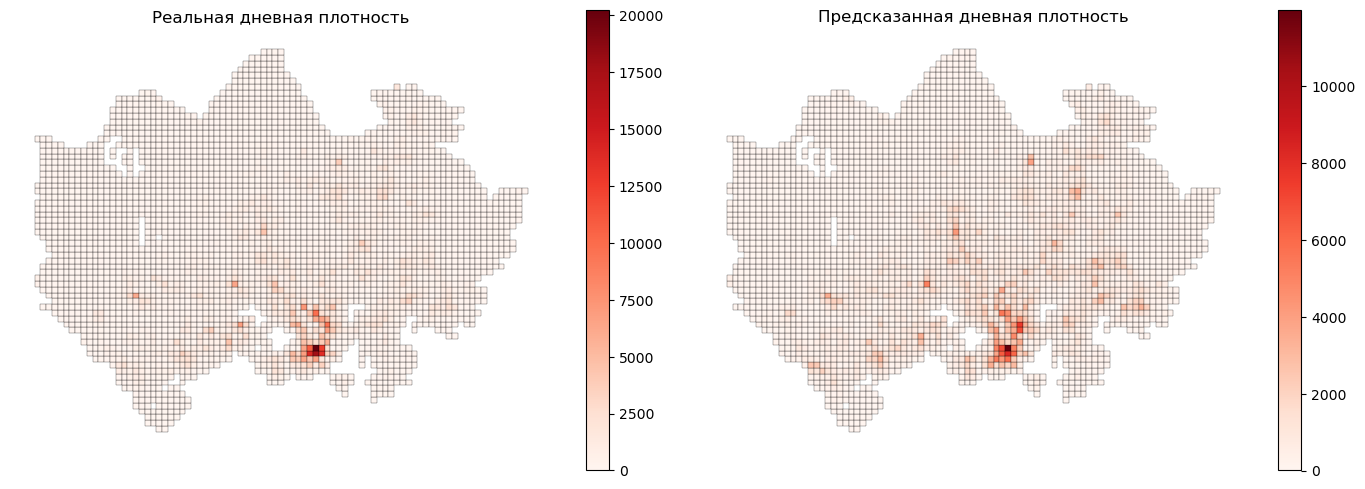

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


gdf.plot(column='daytime_density', ax=ax1, cmap='Reds', legend=True, edgecolor='black', linewidth=0.2)
ax1.set_title('Реальная дневная плотность')
ax1.axis('off')


gdf.plot(column='daytime_density_predicted', ax=ax2, cmap='Reds', legend=True, edgecolor='black', linewidth=0.2)
ax2.set_title('Предсказанная дневная плотность')
ax2.axis('off')

plt.tight_layout()
plt.show()

**Сохранение результатов модели выбора приоритетных возможностей**

In [ ]:
gdf[gdf.columns.drop([col for col in gdf.columns if gdf[col].dtype.name == 'geometry' and col != gdf.geometry.name])].to_file(r"C:\Users\user\Desktop\hse geo\3 Kurs\Курсовая\daytime_population_predicted_ops.gpkg", driver="GPKG")

**Модель возможностей, взвешенных по численности населения**



$$T_{ij} = T_i \frac{m_j (1/S_{ji} - 1/M)}{\sum_{k \neq i} m_k (1/S_{ki} - 1/M)}$$

- **T_i**: Общий отток из *i*
- **m_j**: Возможности в точке назначения (количество точек интереса - POI) в *j*
- **S_ji**: Кумулятивное (накопленное) население вокруг точки назначения *j* 
- **M**: Суммарная численность населения во всех ячейках

In [80]:
gdf = gpd.read_file(GPKG_PATH)
daytime_cols = ['H11', 'H12', 'H13']

nighttime_cols = ['H22', 'H23', 'H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6']

gdf['daytime_density'] = gdf[daytime_cols].mean(axis=1)
gdf['nighttime_density'] = gdf[nighttime_cols].mean(axis=1)

In [75]:
def compute_pwo_flows(T_origin, m_dest, pop_for_S, dist_matrix, eps=1e-10):
    """
    PWO: T_ij = T_i * m_j*(1/S_ji - 1/M) / sum_{k≠i} m_k*(1/S_ki - 1/M)
    S_ji = population within circle centered at j with radius r_ij.
    """
    n = len(T_origin)
    M = pop_for_S.sum()
    m = np.maximum(m_dest, eps)

   
    order_by_j = np.argsort(dist_matrix, axis=1)
    dist_sorted = np.take_along_axis(dist_matrix, order_by_j, axis=1)
    pop_sorted = np.take_along_axis(np.broadcast_to(pop_for_S, (n, n)), order_by_j, axis=1)
    cumsum_pop = np.cumsum(pop_sorted, axis=1)

    T = np.zeros((n, n))
    for i in range(n):
        r_i = dist_matrix[i, :]
        idx = np.array([np.searchsorted(dist_sorted[j], r_i[j], side='right') for j in range(n)])
        S_ji = np.where(idx > 0, cumsum_pop[np.arange(n), idx - 1], 0) + eps
        S_ji[i] = M  

        attr = m * (1.0 / S_ji - 1.0 / M)
        attr = np.maximum(attr, 0)
        attr[i] = 0

        denom = attr.sum()
        if denom < eps:
            P_i = np.ones(n) / (n - 1)
            P_i[i] = 0
        else:
            P_i = attr / denom

        T[i, :] = T_origin[i] * 0.6 * P_i
        T[i, i] = T_origin[i] * 0.4  # остаются дома

    return T



gdf['centroid'] = gdf.geometry.centroid
coords = np.column_stack([gdf['centroid'].x.values, gdf['centroid'].y.values])
dist_matrix = cdist(coords, coords)


T_origin = gdf['nighttime_density'].values
m_dest = gdf['poi_count'].values + 1e-10
pop_for_S = gdf['nighttime_density'].values


T = compute_pwo_flows(T_origin, m_dest, pop_for_S, dist_matrix)

daytime_predicted = T.sum(axis=0)
gdf['daytime_density_predicted'] = daytime_predicted
gdf['daytime_density_residual'] = gdf['daytime_density'] - daytime_predicted

**Оценка модели возможностей, взвешенных по численности населения**

In [77]:
y_actual = gdf["daytime_density"].values
y_pred = gdf["daytime_density_predicted"].values

print(" Population-Weighted Opportunities Model Performance ")
print(f"  R² = {r2_score(y_actual, y_pred):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_actual, y_pred)):.4f}")
print(f"  Корреляция Пирсона: {pearsonr(y_actual, y_pred)[0]:.4f}")
print(f"  MAE = {mean_absolute_error(y_actual, y_pred):.4f}")

 Population-Weighted Opportunities Model Performance 
  R² = 0.6745
  RMSE = 537.8568
  Корреляция Пирсона: 0.8449
  MAE = 173.0017


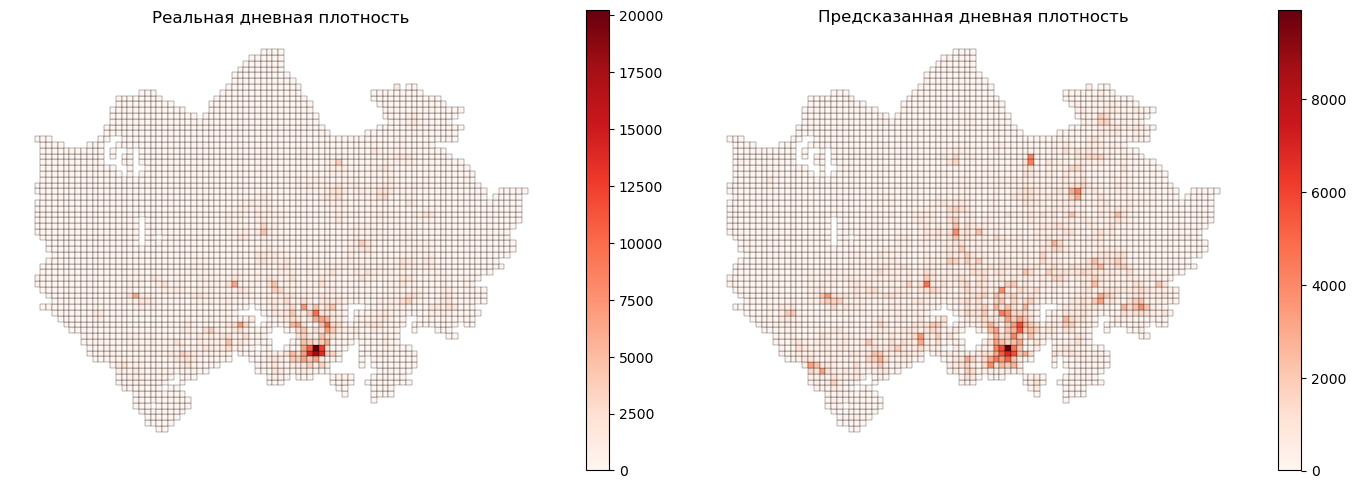

In [78]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


gdf.plot(column='daytime_density', ax=ax1, cmap='Reds', legend=True, edgecolor='black', linewidth=0.2)
ax1.set_title('Реальная дневная плотность')
ax1.axis('off')


gdf.plot(column='daytime_density_predicted', ax=ax2, cmap='Reds', legend=True, edgecolor='black', linewidth=0.2)
ax2.set_title('Предсказанная дневная плотность')
ax2.axis('off')

plt.tight_layout()
plt.show()

**Сохранение результатов модели возможностей, взвешенных по численности населения**

In [ ]:
gdf[gdf.columns.drop([col for col in gdf.columns if gdf[col].dtype.name == 'geometry' and col != gdf.geometry.name])].to_file(r"C:\Users\user\Desktop\hse geo\3 Kurs\Курсовая\daytime_population_predicted_pwo.gpkg", driver="GPKG")